In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as mpl
mpl.rcParams["mathtext.fontset"] = 'cm'
mpl.rcParams["font.size"] = 15
mpl.rcParams["figure.autolayout"] = True

In [2]:
# Load panphage predictions & label by phage

pathPan = 'data/output_panphage_Ignacio_251119/panaroo_default/'
dfPan = pd.read_csv(pathPan + 'predictions.csv', index_col=0)

for i in range(len(dfPan)):
    ph = dfPan.index[i].split('_')[1]
    dfPan.loc[dfPan.index[i], 'phage'] = ph

dfPan['sqError'] = (dfPan['observed'] - dfPan['predicted'])**2

In [3]:
# Paths for single phage predictions

pathSingle = 'data/output_singlephage_Ignacio_251128/panaroo_default/singlephage/'
fns = [f for f in os.listdir(pathSingle) if f.endswith('predictions.csv')]
fns.sort()

phages = [f.split('_')[1] for f in fns]

In [4]:
# Compare predictions

rmse = {}
problems = []
cuSqEr = 0
cuN = 0
dfSin = []

for i in range(len(phages)):
    dfSingle = pd.read_csv(pathSingle + fns[i], index_col=0)
    dfSin += [dfSingle]
    dfSingle['sqError'] = (dfSingle['observed'] - dfSingle['predicted'])**2

    dfSingleTestInt = dfSingle[dfSingle['dataset'] == 'test'].index
    dfPanTestInt = dfPan[(dfPan['dataset'] == 'test') & (dfPan['phage'] == phages[i])].index

    coincidences = dfSingleTestInt.isin(dfPanTestInt).sum()

    nPanTest = len(dfPanTestInt)
    nSinTest = len(dfSingleTestInt)
    nPan = len(dfPan[dfPan['phage'] == phages[i]])
    nSin = len(dfSingle)

    # print(f'{coincidences}/{nSinTest} same interactions used for testing phage {phages[i]}')

    if nPan != 301 or nSin != 301:
        raise NameError()
    if nSinTest != coincidences:
        raise NameError()
        # problems += [phages[i]]

    rmseSin = dfSingle[dfSingle['dataset'] == 'test']['sqError'].mean()**.5
    rmsePan = dfPan[(dfPan['dataset'] == 'test') & (dfPan['phage'] == phages[i])]['sqError'].mean()**.5
    rmseSinTrain = dfSingle['sqError'].mean()**.5
    rmsePanTrain = dfPan[dfPan['phage'] == phages[i]]['sqError'].mean()**.5

    rmse[phages[i]] = {
        'single test': rmseSin,
        'panphage test': rmsePan,
        'single test + train': rmseSinTrain,
        'panphage test + train': rmsePanTrain
    }

    cuN += nSinTest
    cuSqEr += dfSingle[dfSingle['dataset'] == 'test']['sqError'].sum()

singleRMSE = (cuSqEr/cuN)**.5
panphageRMSE = dfPan[dfPan['dataset'] == 'test']['sqError'].mean()**.5

print('Total RMSE:')
print(f'Single phage models: {np.around(singleRMSE,2)}')
print(f'Panphage model: {np.around(panphageRMSE,2)}')

dfSin = pd.concat(dfSin, axis=0)

# Null model prediction:
# Always predict the avg train score

null_pred = dfPan[dfPan['dataset'] == 'train']['observed'].mean()
null_rmse = ((null_pred - dfPan[dfPan['dataset'] == 'test']['observed'])**2).mean()**(1/2)
print(f'Null model: {np.around(null_rmse, 2)}')


Total RMSE:
Single phage models: 19.16
Panphage model: 14.98
Null model: 22.0


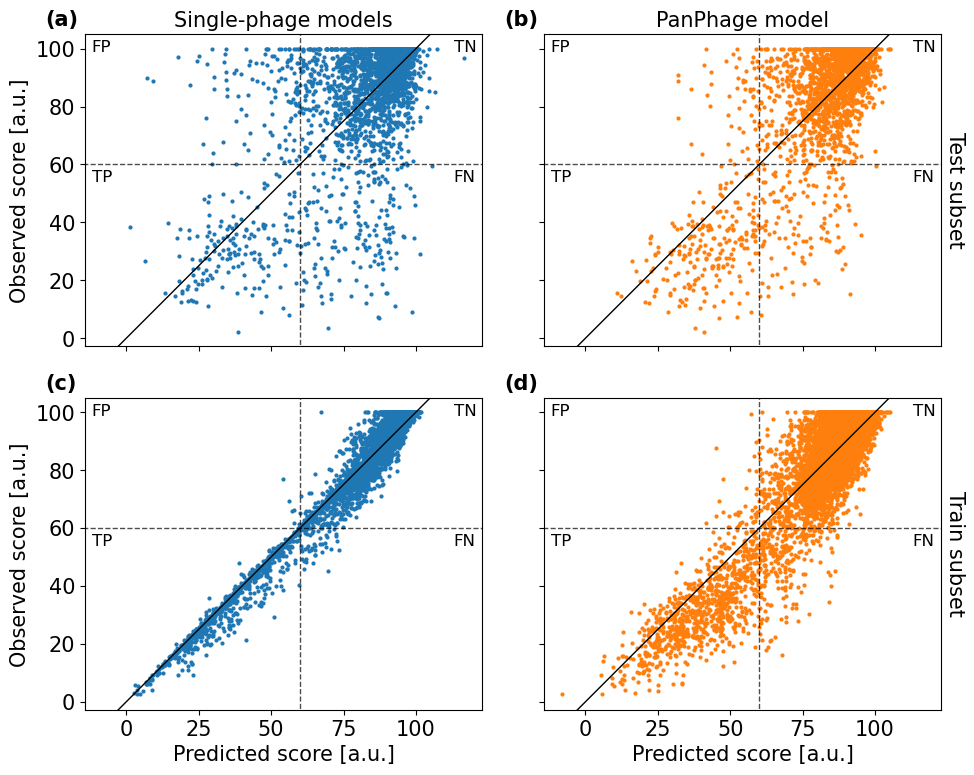

In [5]:
# Fig 2 paper

marker_size = 4

fig, ax = plt.subplots(2,2, figsize=np.array([10, 8]), sharex=True, sharey=True)
ax[0, 0].set_aspect(1)
ax[0, 1].set_aspect(1)
ax[1, 0].set_aspect(1)
ax[1, 1].set_aspect(1)

ax[0, 0].set_ylabel('Observed score [a.u.]')
ax[1, 0].set_ylabel('Observed score [a.u.]')
ax[1, 0].set_xlabel('Predicted score [a.u.]')
ax[1, 1].set_xlabel('Predicted score [a.u.]')

ax[0, 0].set_title('Single-phage models', fontsize=15)
ax[0, 1].set_title('PanPhage model', fontsize=15)

ax[0, 1].text(1.01, 0.5, 'Test subset',
              transform=ax[0, 1].transAxes,
              rotation=270, va='center', ha='left')

ax[1, 1].text(1.01, 0.5, 'Train subset',
              transform=ax[1, 1].transAxes,
              rotation=270, va='center', ha='left')

ax[0, 0].plot(dfSin[dfSin['dataset'] == 'test']['predicted'], dfSin[dfSin['dataset'] == 'test']['observed'], '.', ms=marker_size)
ax[1, 0].plot(dfSin[dfSin['dataset'] == 'train']['predicted'], dfSin[dfSin['dataset'] == 'train']['observed'], '.', ms=marker_size, label='train')
ax[0, 1].plot(dfPan[dfPan['dataset'] == 'test']['predicted'], dfPan[dfPan['dataset'] == 'test']['observed'], '.', ms=marker_size, label='test', c='C1')
ax[1, 1].plot(dfPan[dfPan['dataset'] == 'train']['predicted'], dfPan[dfPan['dataset'] == 'train']['observed'], '.', ms=marker_size, label='train', c='C1')


for axis, label in zip(ax.flat, ['(a)', '(b)', '(c)', '(d)']):
    axis.text(-0.1, 1.08, label,
              transform=axis.transAxes,
              va='top', ha='left',
              fontweight='bold')
    
    axis.add_artist(Line2D([-20, 120], [-20, 120], ls='-', lw=1, c='k', alpha=1))
    axis.add_artist(Line2D([-20, 130], [60, 60], ls='--', lw=1, c='k', alpha=.7))
    axis.add_artist(Line2D([60, 60], [-20, 120], ls='--', lw=1, c='k', alpha=.7))

    axis.text(-12, 99, 'FP', fontsize=12)#, fontweight='bold')
    axis.text(113, 99, 'TN', fontsize=12)#, fontweight='bold')
    axis.text(-12, 54, 'TP', fontsize=12)#, fontweight='bold')
    axis.text(113, 54, 'FN', fontsize=12)#, fontweight='bold')


fig.subplots_adjust(hspace=0.1, wspace=0.1)

path = '../../Alison Low\'s files - Pan_Phage ML manuscript/figures/fig2.png'
# fig.savefig(path, dpi=300)

In [6]:
# Null model for F1 score and phi coeff.:
# No me sirve lo mismo que antes pq tendría 0 retrieved elements
# Voy a usar Bernoulli distribution con probabilidad aprendida del train set

pos = (dfPan[dfPan['dataset'] == 'train']['observed'] <= 60).sum()
n = (dfPan['dataset'] == 'train').sum()
p = pos / n

n_test = (dfPan['dataset'] == 'test').sum()

rng = np.random.default_rng(seed=247407457015144704991800797491156202604)

null_f1 = []
null_phi = []

for i in range(10000):
    predicted_outcomes = (rng.random(size= n_test) <= p).astype(bool)

    observed_outcomes = dfPan[dfPan['dataset'] == 'test']['observed'] <= 60

    true_positives = ((observed_outcomes == predicted_outcomes) & (predicted_outcomes)).sum()
    precision = true_positives / predicted_outcomes.sum()
    recall = true_positives / observed_outcomes.sum()

    null_f1 += [2*(precision**-1 + recall**-1)**-1]

    # phi coefficient
    TN = ((observed_outcomes == predicted_outcomes) & (~predicted_outcomes)).sum()
    FP = ((observed_outcomes != predicted_outcomes) & (predicted_outcomes)).sum()
    FN = ((observed_outcomes != predicted_outcomes) & (~predicted_outcomes)).sum()
    P = true_positives + FN
    N = FP + TN
    predP = true_positives + FP
    predN = TN + FN
    num = true_positives * TN - FP * FN
    den = (P * N * predP * predN) ** .5

    null_phi += [num/den]

print(f'F1 score Null model: {np.mean(null_f1)}')
print(f'φ coeff. Null model: {np.mean(null_phi)}')
print('Se puede demostrar que para este tipo de null models (Bernoulli distributed predictions), φ = 0')

F1 score Null model: 0.14769652573630593
φ coeff. Null model: -0.0005268129360259085
Se puede demostrar que para este tipo de null models (Bernoulli distributed predictions), φ = 0


In [8]:
# Build phage pangenome to plot with comparison between models

# Load pangenomes
interaction_data = pd.read_csv('data/training_data.tsv', delimiter='\t')

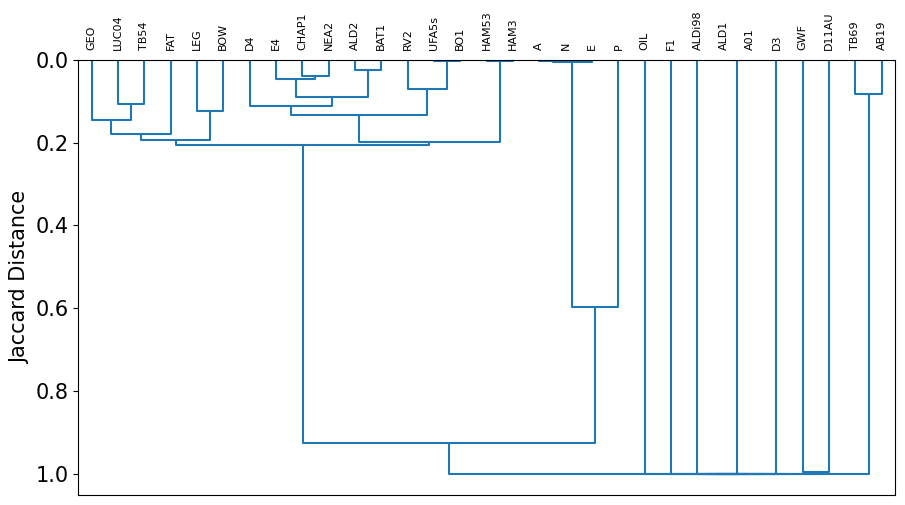

In [9]:
# Tree

rows = interaction_data.index.str.startswith('CAN01_')
cols = interaction_data.columns.str.endswith('_phage')
phage_pangenome = interaction_data.iloc[rows, cols]

metric = 'jaccard'

px = 1/plt.rcParams['figure.dpi']

# Hierarchical clustering (average linkage = good default)
Z = linkage(phage_pangenome, method='average', metric=metric, optimal_ordering=True)

# Plot dendrogram
plt.figure(0, figsize=(930*px, 530*px))
fig, ax = plt.subplots(num=0)

dendrogram(Z, labels=[l[6:] for l in phage_pangenome.index], leaf_rotation=90, color_threshold=0, orientation='bottom')
plt.ylabel("Jaccard Distance")
plt.tight_layout()

plt.show()



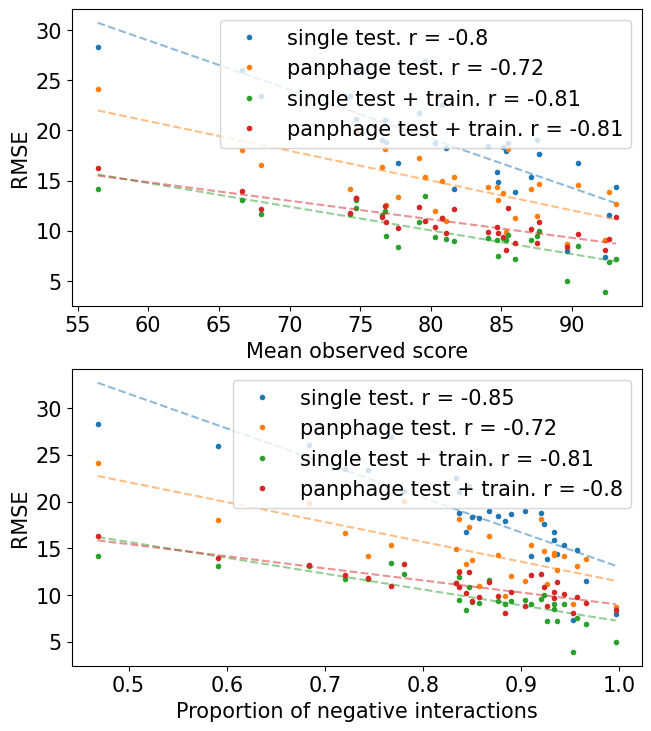

In [10]:
# Plot RMSE vs mean observed score (or % of negative interactions)

meanObsScore = []
pptionNegInt = []

for i in range(len(phages)):
    meanObsScore += [[phages[i], dfPan[dfPan['phage'] == phages[i]]['observed'].mean()]]
    pptionNegInt += [[phages[i], sum(dfPan[dfPan['phage'] == phages[i]]['observed'] > 60) / sum(dfPan['phage'] == phages[i])]]

sortedMOS = pd.DataFrame(meanObsScore, columns=['phage', 'score']).sort_values('score', ignore_index=True)
sortedPNI = pd.DataFrame(pptionNegInt, columns=['phage', 'proportion']).sort_values('proportion', ignore_index=True)

fig, ax = plt.subplots(2, 1, figsize = [6.4, 4.8*1.5])

ax[0].set_xlabel('Mean observed score')
ax[1].set_xlabel('Proportion of negative interactions')
ax[0].set_ylabel('RMSE')
ax[1].set_ylabel('RMSE')


keys = ['single test', 'panphage test', 'single test + train', 'panphage test + train']

for i in range(len(keys)):
    sortedRMSE = [rmse[ph][keys[i]] for ph in sortedMOS['phage']]
    fit = np.polyfit(sortedMOS['score'], sortedRMSE, 1)
    r = pearsonr(sortedMOS['score'], sortedRMSE)
    xFit = np.array([sortedMOS['score'].iloc[0], sortedMOS['score'].iloc[-1]])
    
    ax[0].plot(xFit, fit[0]*xFit + fit[1], '--', c='C'+str(i), alpha=.5)
    ax[0].plot(sortedMOS['score'], sortedRMSE, '.', c='C'+str(i), label=keys[i] + '. r = ' + str(np.around(r[0], 2)))

    sortedRMSE = [rmse[ph][keys[i]] for ph in sortedPNI['phage']]
    fit = np.polyfit(sortedPNI['proportion'], sortedRMSE, 1)
    r = pearsonr(sortedPNI['proportion'], sortedRMSE)
    xFit = np.array([sortedPNI['proportion'].iloc[0], sortedPNI['proportion'].iloc[-1]])

    ax[1].plot(xFit, fit[0]*xFit + fit[1], '--', c='C'+str(i), alpha=.5)
    ax[1].plot(sortedPNI['proportion'], sortedRMSE, '.', c='C'+str(i), label=keys[i] + '. r = ' + str(np.around(r[0], 2)))

ax[1].legend()
ax[0].legend()

fig.set_constrained_layout(1)

In [11]:
# Calculo F1 y phi

# Panphage:
dfPan['predicted infection'] = dfPan['predicted'] < 60
dfPan['observed infection'] = dfPan['observed'] < 60

truePos = (dfPan['observed infection'] & dfPan['predicted infection'] & (dfPan['dataset'] == 'test')).sum()
trueNeg = (~dfPan['observed infection'] & ~dfPan['predicted infection'] & (dfPan['dataset'] == 'test')).sum()
falsePos = (dfPan['predicted infection'] & ~dfPan['observed infection'] & (dfPan['dataset'] == 'test')).sum()
falseNeg = (~dfPan['predicted infection'] & dfPan['observed infection'] & (dfPan['dataset'] == 'test')).sum()

precision = truePos/(truePos + falsePos)
recall = truePos/(truePos + falseNeg)

f1 = 2 * (precision * recall) / (precision + recall)
num = (truePos * trueNeg - falsePos * falseNeg)
den = (truePos + falseNeg) * (trueNeg + falsePos) * (truePos + falsePos) * (trueNeg + falseNeg)
phi = num / den**.5

# Single Phage Models:
cumTP, cumTN, cumFP, cumFN = (0, 0, 0, 0)

for i in range(len(phages)):
    dfSingle = pd.read_csv(pathSingle + fns[i], index_col=0)

    dfSingle['predicted infection'] = dfSingle['predicted'] < 60
    dfSingle['observed infection'] = dfSingle['observed'] < 60

    cumTP += (dfSingle['observed infection'] & dfSingle['predicted infection'] & (dfSingle['dataset'] == 'test')).sum()
    cumTN += (~dfSingle['observed infection'] & ~dfSingle['predicted infection'] & (dfSingle['dataset'] == 'test')).sum()
    cumFP += (dfSingle['predicted infection'] & ~dfSingle['observed infection'] & (dfSingle['dataset'] == 'test')).sum()
    cumFN += (~dfSingle['predicted infection'] & dfSingle['observed infection'] & (dfSingle['dataset'] == 'test')).sum()

f1Single = 2*cumTP / (2*cumTP + cumFP + cumFN)
num = (cumTP * cumTN - cumFP * cumFN)
den = (cumTP + cumFN) * (cumTN + cumFP) * (cumTP + cumFP) * (cumTN + cumFN)
phiSingle = num / den**.5


print('Total F1 scores:')
print(f'Single phage models: {np.around(f1Single,2)}')
print(f'Panphage model: {np.around(f1,2)}')
print('------------------')
print('Total φ coeff.:')
print(f'Single phage models: {np.around(phiSingle,2)}')
print(f'Panphage model: {np.around(phi,2)}')



Total F1 scores:
Single phage models: 0.52
Panphage model: 0.7
------------------
Total φ coeff.:
Single phage models: 0.45
Panphage model: 0.66


In [12]:
# F1 score and phi coeff. for each phage:

f1_phages = {}
phi_phages = {}

cumTPsin, cumTNsin, cumFPsin, cumFNsin = (0, 0, 0, 0)
cumTPpan, cumTNpan, cumFPpan, cumFNpan = (0, 0, 0, 0)

for i in range(len(phages)):
    # Single phage model:
    dfSingle = pd.read_csv(pathSingle + fns[i], index_col=0)

    dfSingle['predicted infection'] = dfSingle['predicted'] < 60
    dfSingle['observed infection'] = dfSingle['observed'] < 60

    tp = (dfSingle['observed infection'] & dfSingle['predicted infection'] & (dfSingle['dataset'] == 'test')).sum()
    tn = (~dfSingle['observed infection'] & ~dfSingle['predicted infection'] & (dfSingle['dataset'] == 'test')).sum()
    fp = (dfSingle['predicted infection'] & ~dfSingle['observed infection'] & (dfSingle['dataset'] == 'test')).sum()
    fn = (~dfSingle['predicted infection'] & dfSingle['observed infection'] & (dfSingle['dataset'] == 'test')).sum()

    preSin = tp/(tp + fp)
    recSin = tp/(tp + fn)

    phiSin = (tp * tn - fp * fn) / ((tp + fn) * (tn + fp) * (tp + fp) * (fn + tn))**.5

    cumTPsin += tp
    cumTNsin += tn
    cumFPsin += fp
    cumFNsin += fn

    # Panphage model:
    tp = (dfPan['observed infection'] & dfPan['predicted infection'] & (dfPan['dataset'] == 'test') & (dfPan['phage'] == phages[i])).sum()
    tn = (~dfPan['observed infection'] & ~dfPan['predicted infection'] & (dfPan['dataset'] == 'test') & (dfPan['phage'] == phages[i])).sum()
    fp = (dfPan['predicted infection'] & ~dfPan['observed infection'] & (dfPan['dataset'] == 'test') & (dfPan['phage'] == phages[i])).sum()
    fn = (~dfPan['predicted infection'] & dfPan['observed infection'] & (dfPan['dataset'] == 'test') & (dfPan['phage'] == phages[i])).sum()

    prePan = tp/(tp + fp)
    recPan = tp/(tp + fn)

    phiPan = (tp * tn - fp * fn) / ((tp + fn) * (tn + fp) * (tp + fp) * (fn + tn))**.5

    cumTPpan += tp
    cumTNpan += tn
    cumFPpan += fp
    cumFNpan += fn


    f1_phages[phages[i]] = {
        'single phage model': 2 * preSin * recSin / (preSin + recSin),
        'panphage model': 2 * prePan * recPan / (prePan + recPan)
    }
    phi_phages[phages[i]] = {
        'single phage model': phiSin,
        'panphage model': phiPan
    }

    cond_sin = preSin == 0 or recSin == 0
    if cond_sin:
        f1_phages[phages[i]]['single phage model'] = 0

    cond_pan = prePan == 0 or recPan == 0
    if cond_pan:
        f1_phages[phages[i]]['panphage model'] = 0

/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/924901204.py:37: RuntimeWarning: invalid value encountered in scalar divide
  prePan = tp/(tp + fp)
/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/924901204.py:40: RuntimeWarning: invalid value encountered in scalar divide
  phiPan = (tp * tn - fp * fn) / ((tp + fn) * (tn + fp) * (tp + fp) * (fn + tn))**.5
/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/924901204.py:49: RuntimeWarning: invalid value encountered in scalar divide
  'single phage model': 2 * preSin * recSin / (preSin + recSin),
/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/924901204.py:21: RuntimeWarning: invalid value encountered in scalar divide
  preSin = tp/(tp + fp)
/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/924901204.py:22: RuntimeWarning: invalid value encountered in scalar divide
  recSin = tp/(tp + fn)
/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/92490120

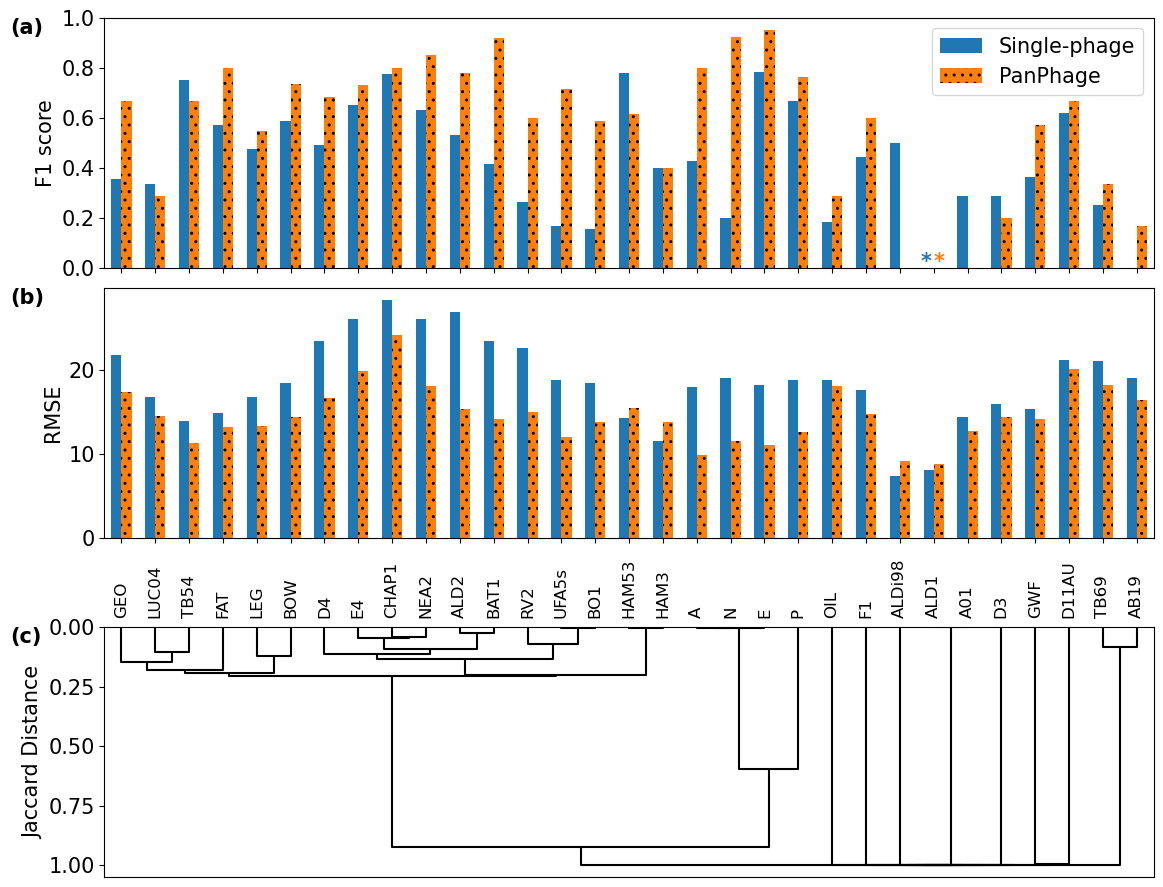

In [13]:
# Fig 3 paper (sin \phi):

fig, ax = plt.subplots(3,1, figsize=[11.52, 11.52 * .76], sharex=True) 

dendrogram(Z, labels=[l[6:] for l in phage_pangenome.index], leaf_rotation=90, 
           color_threshold=0, orientation='bottom', ax=ax[-1], leaf_font_size=12,
           above_threshold_color='k')

fagos = ax[-1].get_xticklabels()
w = 3

for i in range(len(fagos)):
    x = fagos[i].get_position()[0]
    sin = rmse[fagos[i].get_text()]['single test']
    pan = rmse[fagos[i].get_text()]['panphage test']

    bar1 = ax[1].bar([x - w/2], [sin], width=w, color='C0')#, hatch='\\\\')
    bar2 = ax[1].bar([x + w/2], [pan], width=w, color='C1', hatch='..')

# ax[1].legend([bar1, bar2], ['Single phage', 'Panphage'])

ax[1].set_ylabel('RMSE')
ax[-1].set_ylabel('Jaccard Distance')

y = .0

for i in range(len(fagos)):
    x = fagos[i].get_position()[0]
    sin = f1_phages[fagos[i].get_text()]['single phage model']
    pan = f1_phages[fagos[i].get_text()]['panphage model']

    bar1 = ax[0].bar([x - w/2], [sin], width=w, color='C0')
    bar2 = ax[0].bar([x + w/2], [pan], width=w, color='C1', hatch='..')

    if np.isnan(sin):
        ax[0].text(x - 4., y, '*', size=15, weight=1000, color='C0')
    if np.isnan(pan):
        ax[0].text(x - 0.1, y, '*', size=15, weight=1000, color='C1')


# manual_element = Line2D([0], [0], ls='', marker='$*$', color='k', alpha=.6)
# ax[0].legend([bar1, bar2, manual_element], ['Single phage', 'Panphage', 'F1 score undefined'], loc='upper right')
ax[0].legend([bar1, bar2], ['Single-phage', 'PanPhage'], loc='upper right')

ax[0].set_ylabel('F1 score')

# for i in range(len(fagos)):
#     x = fagos[i].get_position()[0]
#     sin = phi_phages[fagos[i].get_text()]['single phage model']
#     pan = phi_phages[fagos[i].get_text()]['panphage model']

#     bar1 = ax[2].bar([x - w/2], [sin], width=w, color='C0')
#     bar2 = ax[2].bar([x + w/2], [pan], width=w, color='C1', hatch='..')

#     if np.isnan(sin):
#         ax[2].text(x - 4., y, '*', size=15, weight=1000, color='C0')
#     if np.isnan(pan):
#         ax[2].text(x - 0.1, y, '*', size=15, weight=1000, color='C1')


# manual_element = Line2D([0], [0], ls='', marker='$*$', color='k', alpha=.6)
# ax[2].legend([bar1, bar2, manual_element], ['Single phage', 'Panphage', r'$\phi$ undefined'], loc='upper right')

# ax[2].set_ylabel(r'$\phi$ coefficient')
# ax[2].set_ylim([-0.145, 1])

for axis, label in zip(ax.flat, ['(a)', '(b)', '(c)']):
    axis.text(-0.09, 1.0, label,
              transform=axis.transAxes,
              va='top', ha='left',
              fontweight='bold')

fig.set_constrained_layout(True)

path = '../../Alison Low\'s files - Pan_Phage ML manuscript/figures/Fig 3 combined_RSME_F1_coefficient.png'
# fig.savefig(path, dpi=300)

In [14]:
# Calculate precision and recall

pre_rec_phages = {}

for i in range(len(phages)):
    # Single phage model:
    dfSingle = pd.read_csv(pathSingle + fns[i], index_col=0)

    dfSingle['predicted infection'] = dfSingle['predicted'] < 60
    dfSingle['observed infection'] = dfSingle['observed'] < 60

    tp = (dfSingle['observed infection'] & dfSingle['predicted infection'] & (dfSingle['dataset'] == 'test')).sum()
    tn = (~dfSingle['observed infection'] & ~dfSingle['predicted infection'] & (dfSingle['dataset'] == 'test')).sum()
    fp = (dfSingle['predicted infection'] & ~dfSingle['observed infection'] & (dfSingle['dataset'] == 'test')).sum()
    fn = (~dfSingle['predicted infection'] & dfSingle['observed infection'] & (dfSingle['dataset'] == 'test')).sum()

    preSin = tp/(tp + fp)
    recSin = tp/(tp + fn)

    # if any(np.isnan([preSin, recSin])):
    #     break

    # Panphage model:
    tp = (dfPan['observed infection'] & dfPan['predicted infection'] & (dfPan['dataset'] == 'test') & (dfPan['phage'] == phages[i])).sum()
    tn = (~dfPan['observed infection'] & ~dfPan['predicted infection'] & (dfPan['dataset'] == 'test') & (dfPan['phage'] == phages[i])).sum()
    fp = (dfPan['predicted infection'] & ~dfPan['observed infection'] & (dfPan['dataset'] == 'test') & (dfPan['phage'] == phages[i])).sum()
    fn = (~dfPan['predicted infection'] & dfPan['observed infection'] & (dfPan['dataset'] == 'test') & (dfPan['phage'] == phages[i])).sum()

    prePan = tp/(tp + fp)
    recPan = tp/(tp + fn)


    pre_rec_phages[phages[i]] = {
        'single precision': preSin,
        'single recall': recSin,
        'panphage precision': prePan,
        'panphage recall': recPan
    }

    # if any(v != v for v in pre_rec_phages[phages[i]].values()):
    #     if i != 0:
    #         break

/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/3366845327.py:29: RuntimeWarning: invalid value encountered in scalar divide
  prePan = tp/(tp + fp)
/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/3366845327.py:17: RuntimeWarning: invalid value encountered in scalar divide
  preSin = tp/(tp + fp)
/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/3366845327.py:18: RuntimeWarning: invalid value encountered in scalar divide
  recSin = tp/(tp + fn)
/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/3366845327.py:29: RuntimeWarning: invalid value encountered in scalar divide
  prePan = tp/(tp + fp)
/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/3366845327.py:30: RuntimeWarning: invalid value encountered in scalar divide
  recPan = tp/(tp + fn)
/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14359/3366845327.py:29: RuntimeWarning: invalid value encountered in scalar divide
  prePan = tp/(tp + fp)


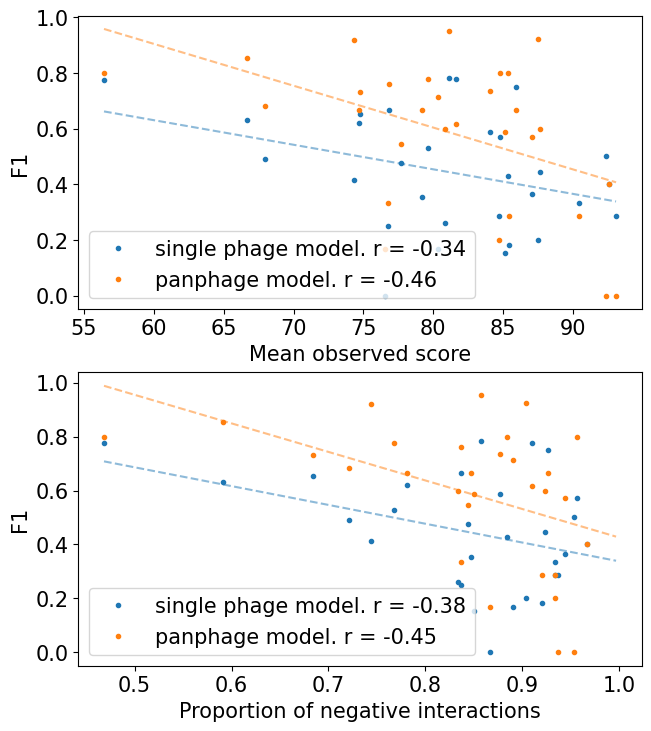

In [16]:
# Plot F1 vs mean observed score (or % of negative interactions)

fig, ax = plt.subplots(2, 1, figsize = [6.4, 4.8*1.5])

ax[0].set_xlabel('Mean observed score')
ax[1].set_xlabel('Proportion of negative interactions')
ax[0].set_ylabel('F1', rotation=90)
ax[1].set_ylabel('F1', rotation=90)

keys = ['single phage model', 'panphage model']

for i in range(len(keys)):
    sortedF1 = np.array([f1_phages[ph][keys[i]] for ph in sortedMOS['phage']])
    mask = ~np.isnan(sortedF1)
    fit = np.polyfit(sortedMOS['score'][mask], sortedF1[mask], 1)
    r = pearsonr(sortedMOS['score'][mask], sortedF1[mask])
    xFit = np.array([sortedMOS['score'].iloc[0], sortedMOS['score'].iloc[-1]])
    
    ax[0].plot(xFit, fit[0]*xFit + fit[1], '--', c='C'+str(i), alpha=.5)
    ax[0].plot(sortedMOS['score'], sortedF1, '.', c='C'+str(i), label=keys[i] + '. r = ' + str(np.around(r[0], 2)))

    sortedF1 = np.array([f1_phages[ph][keys[i]] for ph in sortedPNI['phage']])
    mask = ~np.isnan(sortedF1)
    fit = np.polyfit(sortedPNI['proportion'][mask], sortedF1[mask], 1)
    r = pearsonr(sortedPNI['proportion'][mask], sortedF1[mask])
    xFit = np.array([sortedPNI['proportion'].iloc[0], sortedPNI['proportion'].iloc[-1]])

    ax[1].plot(xFit, fit[0]*xFit + fit[1], '--', c='C'+str(i), alpha=.5)
    ax[1].plot(sortedPNI['proportion'], sortedF1, '.', c='C'+str(i), label=keys[i] + '. r = ' + str(np.around(r[0], 2)))

ax[1].legend()
ax[0].legend()

fig.set_constrained_layout(1)

r = 0.3763405238421285
0.038886
r = 0.45456351083936913
0.01158
r = 0.8524416967990479
0.0
r = 0.7219870365887765
1e-05


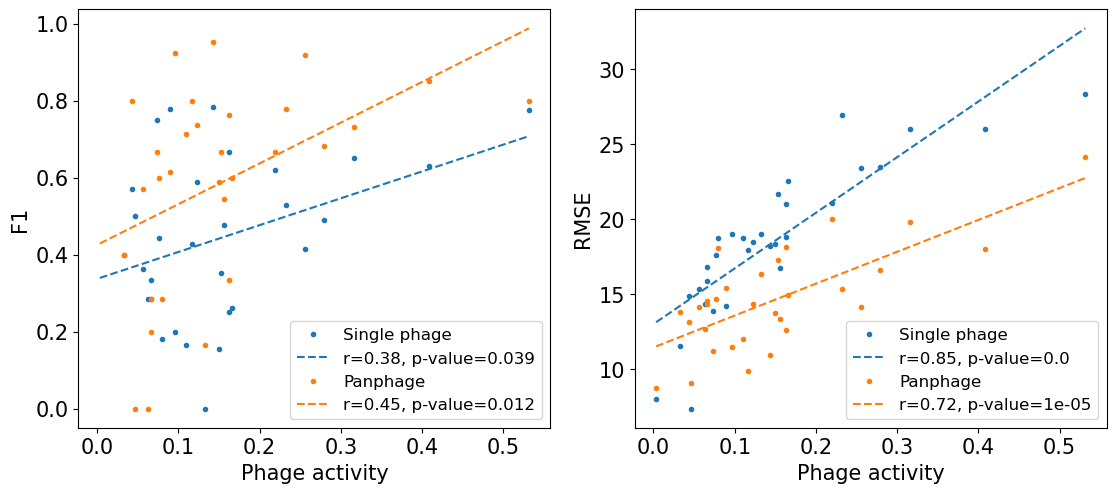

In [17]:
# Figure F1, RMSE, Precision, Recall v/s phage activity

fagos = np.flip(sortedPNI['phage'].values)
activity = np.flip(1 - sortedPNI['proportion'].values)

F1_sin = np.array([f1_phages[ph]['single phage model'] for ph in fagos])
F1_pan = np.array([f1_phages[ph]['panphage model'] for ph in fagos])
RMSE_sin = np.array([rmse[ph]['single test'] for ph in fagos])
RMSE_pan = np.array([rmse[ph]['panphage test'] for ph in fagos])
Precision_sin = np.array([pre_rec_phages[ph]['single precision'] for ph in fagos])
Precision_pan = np.array([pre_rec_phages[ph]['panphage precision'] for ph in fagos])
Recall_sin = np.array([pre_rec_phages[ph]['single recall'] for ph in fagos])
Recall_pan = np.array([pre_rec_phages[ph]['panphage recall'] for ph in fagos])

data_matrix = np.array([[[F1_sin, F1_pan], [RMSE_sin, RMSE_pan]],
                        [[Precision_sin, Precision_pan], [Recall_sin, Recall_pan]]])

seed = 58507382018297502996383464561620528039
rng = np.random.default_rng(seed=seed)

ylabels = [['F1', 'RMSE'], ['Precision', 'Recall']]
xFit = np.array([activity[0], activity[-1]])

# fig, ax = plt.subplots(2, 2, sharex=True, figsize=np.array([6.4, 4.8])*1.5)
fig, ax = plt.subplots(1, 2, sharex=True, squeeze=False, figsize=np.array([29, 15.5*.85])/2.54)#[6.4 * 1.5, 4.8 * .8]))

# for i in range(2):
for i in range(1):
    for j in range(2):
        ax[i, j].set_ylabel(ylabels[i][j])
        
        for k in range(2):
            # Linear regression:
            mask = ~np.isnan(data_matrix[i, j, k])
            fit = np.polyfit(activity[mask], data_matrix[i, j, k][mask], 1)
            r = pearsonr(activity[mask], data_matrix[i, j, k][mask]).statistic
            print(f'r = {r}')
            
            # p-value:
            r_perm = []
            for l in range(1000000):
                permuted_data = rng.permuted(data_matrix[i, j, k], axis=0)
                mask = ~np.isnan(permuted_data)
                r_perm += [pearsonr(activity[mask], permuted_data[mask]).statistic]
            r_perm = np.array(r_perm)
            p = (abs(r_perm) >= abs(r)).sum() / len(r_perm)

            # Plot:
            ax[i, j].plot(activity, data_matrix[i, j, k], '.', c='C'+str(k), label=['Single phage', 'Panphage'][k])
            print(p)
            if p < 0.01:
                label = f'r={np.around(r, 2)}, p-value={np.around(p,10)}'
                
            else:
                label = f'r={np.around(r, 2)}, p-value={np.around(p,3)}'
            ax[i, j].plot(xFit, fit[0]*xFit + fit[1], '--', c='C'+str(k), alpha=1, label=label)
        
        ax[i, j].legend(fontsize=12)

# ax[1, 0].set_xlabel('Phage activity')
# ax[1, 1].set_xlabel('Phage activity')
ax[0, 0].set_xlabel('Phage activity')
ax[0, 1].set_xlabel('Phage activity')

fig.tight_layout()

# plt.savefig('appendix_performance_vs_phage_activity.svg')

0.8725
0.2596


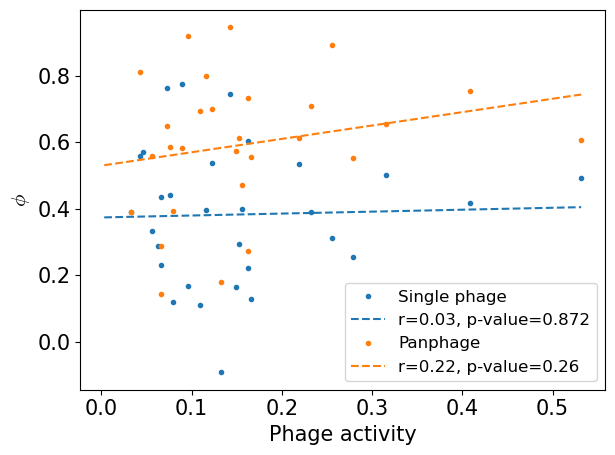

In [ ]:
# phi vs phage activity

PHI_sin = np.array([phi_phages[ph]['single phage model'] for ph in fagos])
PHI_pan = np.array([phi_phages[ph]['panphage model'] for ph in fagos])

data = np.array([PHI_sin, PHI_pan])

seed = 154456191738048759402266036248939572602
rng = np.random.default_rng(seed=seed)

xFit = np.array([activity[0], activity[-1]])

fig, ax = plt.subplots()

ax.set_ylabel(r'$\phi$')

for k in range(2):
    # Linear regression:
    mask = ~np.isnan(data[k])
    fit = np.polyfit(activity[mask], data[k][mask], 1)
    r = pearsonr(activity[mask], data[k][mask]).statistic
    
    # p-value:
    r_perm = []
    for l in range(10000):
        permuted_data = rng.permuted(data[k], axis=0)
        mask = ~np.isnan(permuted_data)
        r_perm += [pearsonr(activity[mask], permuted_data[mask]).statistic]
    r_perm = np.array(r_perm)
    p = (abs(r_perm) >= abs(r)).sum() / len(r_perm)

    # Plot:
    ax.plot(activity, data[k], '.', c='C'+str(k), label=['Single phage', 'Panphage'][k])
    print(p)
    if p < 0.01:
        label = f'r={np.around(r, 2)}, p-value={np.around(p,10)}'
    else:
        label = f'r={np.around(r, 2)}, p-value={np.around(p,3)}'
    ax.plot(xFit, fit[0]*xFit + fit[1], '--', c='C'+str(k), alpha=1, label=label)

ax.legend(fontsize=12)

ax.set_xlabel('Phage activity')

fig.tight_layout()

# plt.savefig('appendix_performance_vs_phage_activity.svg')
plt.show()

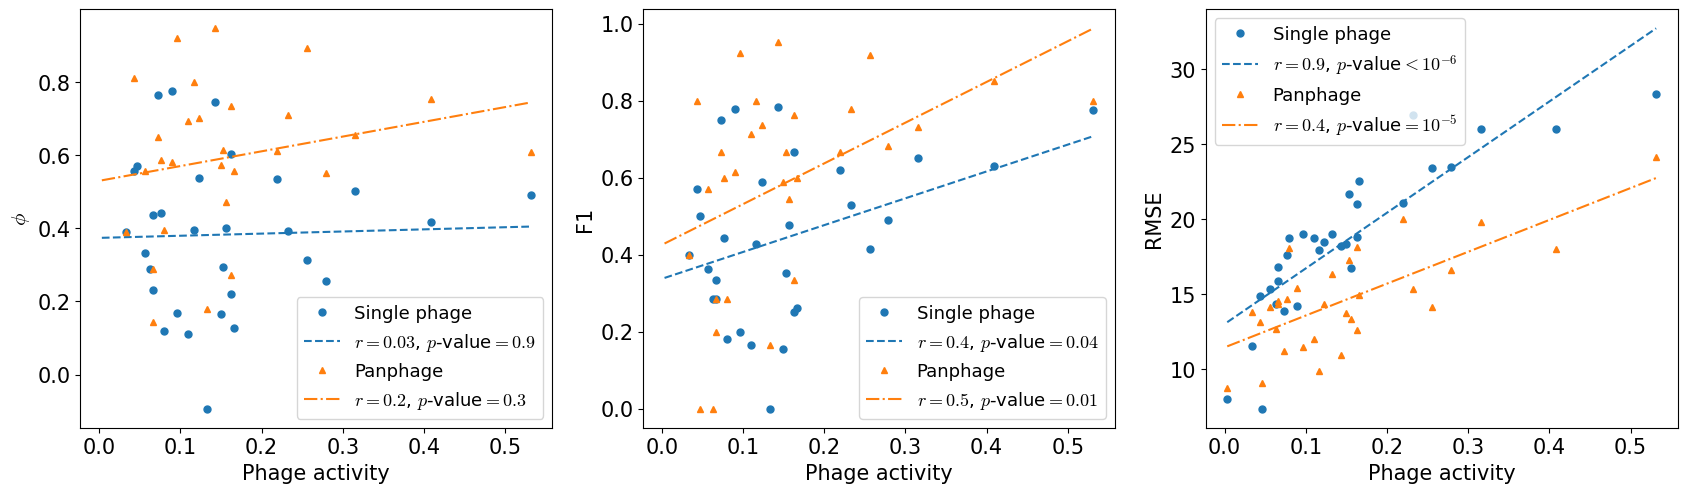

In [ ]:
# Repetir figuras sin cálculo de p-value (por tiempo)

data_matrix = np.array([[PHI_sin, PHI_pan], [F1_sin, F1_pan], [RMSE_sin, RMSE_pan]])

ylabels = [r'$\phi$', 'F1', 'RMSE']
xFit = np.array([activity[0], activity[-1]])

fig, ax = plt.subplots(1, 3, sharex=True, figsize=np.array([29*3/2, 15.5*.85])/2.54)

labels = [[r'$r=0.03$, $p$-value$=0.9$', r'$r=0.2$, $p$-value$=0.3$'],
          [r'$r=0.4$, $p$-value$=0.04$', r'$r=0.5$, $p$-value$=0.01$'],
          [r'$r=0.9$, $p$-value$<10^{-6}$', r'$r=0.4$, $p$-value$=10^{-5}$']]

for j in range(3):
    ax[j].set_ylabel(ylabels[j])
    
    for k in range(2):
        # Linear regression:
        mask = ~np.isnan(data_matrix[j, k])
        fit = np.polyfit(activity[mask], data_matrix[j, k][mask], 1)
        r = pearsonr(activity[mask], data_matrix[j, k][mask]).statistic

        # Plot:
        ax[j].plot(activity, data_matrix[j, k], ['o', '^'][k], ms=5, c='C'+str(k), label=['Single phage', 'Panphage'][k])
        ax[j].plot(xFit, fit[0]*xFit + fit[1], ['--', '-.'][k], c='C'+str(k), alpha=1, label=labels[j][k])
    
    ax[j].legend(fontsize=13)#, loc='lower right')


ax[0].set_xlabel('Phage activity')
ax[1].set_xlabel('Phage activity')
ax[2].set_xlabel('Phage activity')

fig.tight_layout()


path = '../../Alison Low\'s files - Pan_Phage ML manuscript/figures/appendix_performance_vs_phage_activity.png'
# fig.savefig(path, dpi=300)
plt.show()

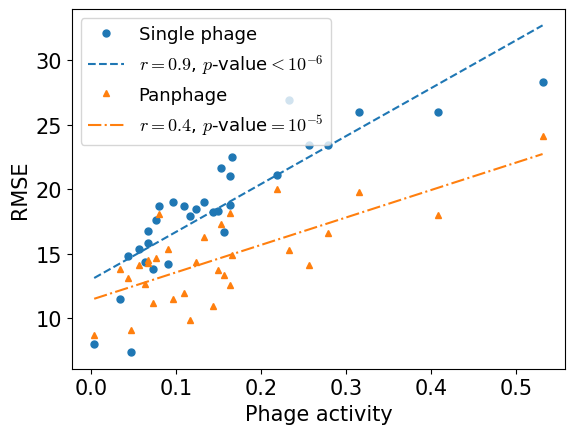

In [ ]:
# RMSE vs Activity alone for SM

fig, ax = plt.subplots(1, 1, figsize=np.array([6, 4.6]))

for j in range(2,3):
    ax.set_ylabel(ylabels[j])
    
    for k in range(2):
        # Linear regression:
        mask = ~np.isnan(data_matrix[j, k])
        fit = np.polyfit(activity[mask], data_matrix[j, k][mask], 1)
        r = pearsonr(activity[mask], data_matrix[j, k][mask]).statistic

        # Plot:
        ax.plot(activity, data_matrix[j, k], ['o', '^'][k], ms=5, c='C'+str(k), label=['Single phage', 'Panphage'][k])
        ax.plot(xFit, fit[0]*xFit + fit[1], ['--', '-.'][k], c='C'+str(k), alpha=1, label=labels[j][k])
    
    ax.legend(fontsize=13)


ax.set_xlabel('Phage activity')

fig.tight_layout()


path = '../../Alison Low\'s files - Pan_Phage ML manuscript/figures/appendix_performance_vs_phage_activity.png'
# fig.savefig(path, dpi=300)

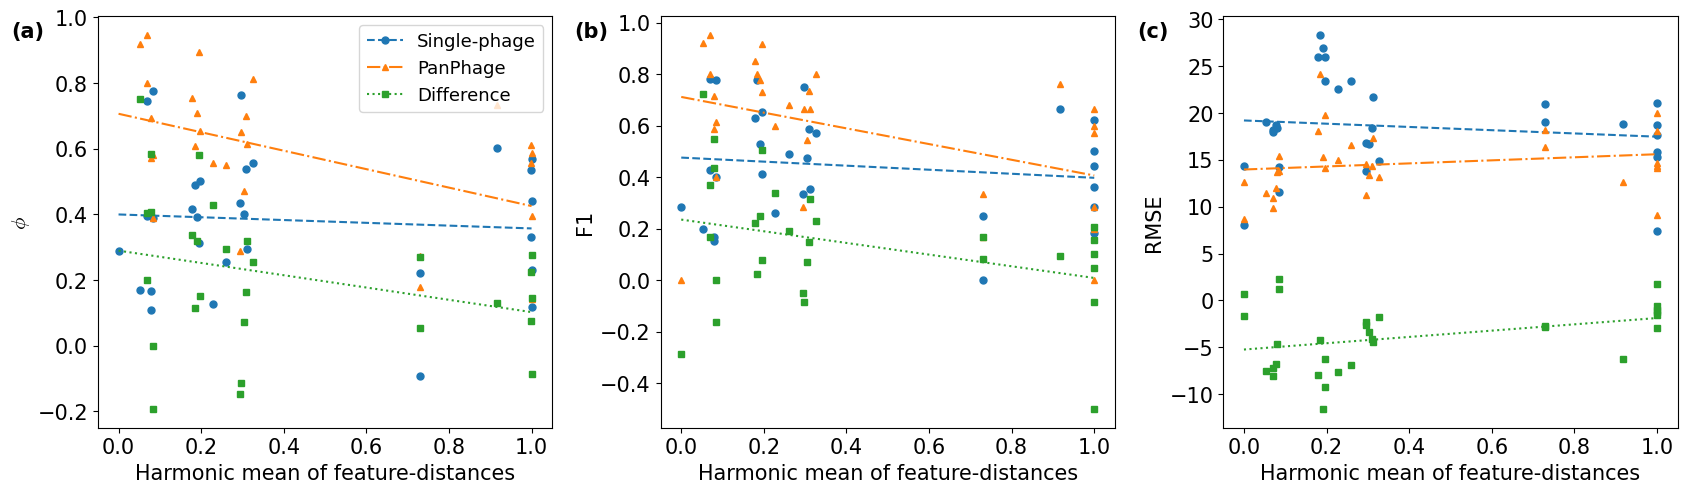

In [ ]:
# Fig. S4
# \phi, F1 and RMSE against Harmonic mean of feature-distances
# For single-phage models, PanPhage model and the relative diference (sin - pan)/sin

feature_distances = pd.read_csv('data/feature_distances.csv', index_col='phage')
feature_distances.sort_values('IMID', axis=0, inplace=True)
fagos = feature_distances.index.values
distance = feature_distances['IMID'].values

F1_sin = np.array([f1_phages[ph]['single phage model'] for ph in fagos])
F1_pan = np.array([f1_phages[ph]['panphage model'] for ph in fagos])
RMSE_sin = np.array([rmse[ph]['single test'] for ph in fagos])
RMSE_pan = np.array([rmse[ph]['panphage test'] for ph in fagos])
PHI_sin = np.array([phi_phages[ph]['single phage model'] for ph in fagos])
PHI_pan = np.array([phi_phages[ph]['panphage model'] for ph in fagos])

data_matrix = np.array([[PHI_sin, PHI_pan], [F1_sin, F1_pan], [RMSE_sin, RMSE_pan]])

ylabels = [r'$\phi$', 'F1', 'RMSE']
xFit = np.array([distance[0], distance[-1]])

fig, ax = plt.subplots(1, 3, figsize=np.array([29*3/2, 15.5*.85])/2.54)

ms = 5

caption = ['(a)', '(b)', '(c)']

for j in range(3):
    ax[j].set_ylabel(ylabels[j])
    
    for k in range(2):
        # Linear regression:
        mask = ~np.isnan(data_matrix[j, k])
        fit = np.polyfit(distance[mask], data_matrix[j, k][mask], 1)

        # Plot:
        ax[j].plot(distance, data_matrix[j, k],['o', '^'][k], ms=ms, c='C'+str(k), label=['Single phage', 'Panphage'][k])
        ax[j].plot(xFit, fit[0]*xFit + fit[1], ['--', '-.'][k], c='C'+str(k), alpha=1)

    # Plot differences:
    data = data_matrix[j, 1] - data_matrix[j, 0]
    mask = ~np.isnan(data)
    fit = np.polyfit(distance[mask], data[mask], 1)

    ax[j].plot(distance, data, 's', ms=ms, c='C2')
    ax[j].plot(xFit, fit[0]*xFit + fit[1], ':', c='C2')

    ax[j].text(-.19, .95, caption[j], transform=ax[j].transAxes, fontweight='bold')

ax[0].set_xlabel('Harmonic mean of feature-distances')
ax[1].set_xlabel('Harmonic mean of feature-distances')
ax[2].set_xlabel('Harmonic mean of feature-distances')

# Legend

sin_line = Line2D([], [], color='C0', marker='o', ms=ms, ls='--', label='Single-phage')
pan_line = Line2D([], [], color='C1', marker='^', ms=ms, ls='-.', label='PanPhage')
dif_line = Line2D([], [], color='C2', marker='s', ms=ms, ls=':', label='Difference')
ax[0].legend(handles=[sin_line, pan_line, dif_line], fontsize=13)

fig.tight_layout()

path = '../../Alison Low\'s files - Pan_Phage ML manuscript/figures/appendix_performance_vs_feature_distance_1.png'
# fig.savefig(path, dpi=300)

In [ ]:
# p-values

seed = 257341245399648287100871890079624183840
rng = np.random.default_rng(seed=seed)

for j in range(3):
    print(f'{ylabels[j]}')
    for k in range(2):
        
        # Linear regression:
        mask = ~np.isnan(data_matrix[j, k])
        fit = np.polyfit(distance[mask], data_matrix[j, k][mask], 1)
        r = pearsonr(distance[mask], data_matrix[j, k][mask]).statistic

        # p-value:
        r_perm = []
        for l in range(9999):
            permuted_data = rng.permuted(data_matrix[j, k], axis=0)
            mask = ~np.isnan(permuted_data)
            r_perm += [pearsonr(distance[mask], permuted_data[mask]).statistic]
        r_perm = np.array(r_perm)
        p = (abs(r_perm) >= abs(r)).sum() / len(r_perm)

        print(['Single-phage', 'PanPhage'][k])
        print(f'r = {np.around(r,4)}')
        print(f'p = {np.around(p,4)}')

    # Diference:
    data = data_matrix[j, 1] - data_matrix[j, 0]
    mask = ~np.isnan(data)
    r = pearsonr(distance[mask], data[mask]).statistic

    # p-value:
    r_perm = []
    for l in range(9999):
        permuted_data = rng.permuted(data, axis=0)
        mask = ~np.isnan(permuted_data)
        r_perm += [pearsonr(distance[mask], permuted_data[mask]).statistic]
    r_perm = np.array(r_perm)
    p = (abs(r_perm) >= abs(r)).sum() / len(r_perm)

    print('Difference')
    print(f'r = {np.around(r,4)}')
    print(f'p = {np.around(p,4)}')

$\phi$
Single-phage
r = -0.075
p = 0.6914
PanPhage
r = -0.4755
p = 0.0104
Difference
r = -0.2934
p = 0.1314
F1
Single-phage
r = -0.1366
p = 0.4721
PanPhage
r = -0.4227
p = 0.0218
Difference
r = -0.3361
p = 0.072
RMSE
Single-phage
r = -0.1272
p = 0.5001
PanPhage
r = 0.1771
p = 0.3442
Difference
r = 0.3586
p = 0.0483
